# Assignment 2 2AMM10 2025-2026

## Group: [DL group]
### Member 1: [Hannes Janmaat 1548999]
### Member 2: [Benjamin Softic 1573608]
### Member 3: [Deins Kovalcuks 1847031]

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch_geometric

from torch_geometric.loader import DataLoader

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.4 MB/s eta 0:00:00


In [3]:
import torch
import json
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "/content/drive/MyDrive/2amm10/data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

# Task 1

In [4]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

<Axes: >

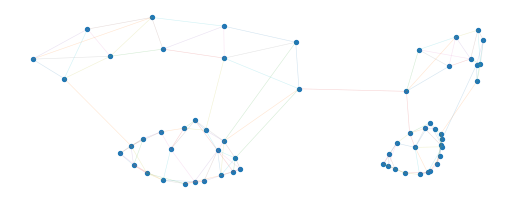

In [5]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

In [7]:
class Node_to_emb(nn.Module):
    def __init__(self, node_feat_dim=14, node_emb_dim=64):
        super().__init__()
        self.emb_dim = node_emb_dim
        self.node_dim = node_feat_dim
        self.emb = nn.Linear(self.node_dim, self.emb_dim)


    def forward(self, nodes):
        out = self.emb(nodes)
        return out

In [8]:
class MpLayer(torch.nn.Module):  # a neural message passing layer
    def __init__(self, hidden_dim, activation=nn.ReLU()):
        super(MpLayer, self).__init__()
        self.edge_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          activation
                                          )

        self.node_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          )

    def forward(self, input_to_layer):
        node_tensor, edge_idx_tensor = input_to_layer
        edge_messages_input = torch.concat([node_tensor[edge_idx_tensor[0,:]], node_tensor[edge_idx_tensor[1,:]]], dim=-1) # shape (num_edges, 2*node_dim)
        edge_messages_output = self.edge_network(edge_messages_input) # shape (num_edges, hidden_dim)

        #now aggregate the edge messages for each node the edge points to:

        node_agg_messages = torch.zeros(node_tensor.size(0), node_tensor.size(1)).to(node_tensor.device)
        node_agg_messages = node_agg_messages.scatter_add_(
            dim=0, index=edge_idx_tensor[1].unsqueeze(-1).expand(-1, node_tensor.size(1)), src=edge_messages_output
        )

        #### why does the aggregation function need to be permutationally invariant? What is another aggregation function
        #### that could be used?

        #put the aggregated messages through the node update network:
        node_out = self.node_network(torch.cat([node_tensor, node_agg_messages], dim=-1))

        return node_out, edge_idx_tensor

In [9]:
class DrowsyGNN(torch.nn.Module): # a message passing GNN
    def __init__(self, node_feat_dim, hidden_dim, activation=nn.ReLU(), num_layers=3, num_classes=2):
        super(DrowsyGNN, self).__init__()
        self.node_to_emb = Node_to_emb(node_feat_dim, hidden_dim)
        self.forward_net = nn.Sequential(
            *[MpLayer(hidden_dim, activation) for i in range(num_layers)]
        )
        self.to_pred = nn.Linear(hidden_dim, num_classes)



    def forward(self, x, edge_index, batch):
        x = self.node_to_emb(x)
        input_model = (x, edge_index)
        output_model = self.forward_net(input_model)
        x,_ = output_model

        out = torch.zeros(max(batch)+1, x.size(1)).to(x.device)
        idx_aggregate_graph = batch.unsqueeze(-1).expand(-1, x.size(1))


        out.scatter_add_(dim=0, index=idx_aggregate_graph, src=x) # aggregate all node embeddings per graph in the batch

        x = self.to_pred(out)
        return x

In [10]:
#in_channels  = train_dataset[0].x.shape[1]   # 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DrowsyGNN(3, 32, num_layers=4).to(device)
optimizer = torch.optim.Adam(model.parameters())  # adam usually works well
loss_func = torch.nn.CrossEntropyLoss()  # binary classification, so crossentropy is a suitable loss

def train():
    model.train()
    total_loss = 0
    total = 0

    for data in train_loader:
        data = data.to(device)

        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = loss_func(out, data.y.long())

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs
        total += data.num_graphs

    return total_loss / total


def test(loader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data.x, data.edge_index, data.batch)
            loss = loss_func(out, data.y.long())

            pred = out.argmax(dim=1)

            total_loss += loss.item() * data.num_graphs
            correct += int((pred == data.y).sum())
            total += len(data.y)

            all_preds.append(pred.cpu())
            all_labels.append(data.y.cpu())

    avg_loss = total_loss / total
    acc = correct / total

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    return avg_loss, acc, preds, labels

In [17]:
train_losses = []
test_losses = []
train_accs = []
test_accs = []

epochs = 100

for epoch in range(1, epochs + 1):
    train_loss = train()

    train_eval_loss, train_acc, _, _ = test(train_loader)
    test_loss, test_acc, _, _ = test(test_loader)

    train_losses.append(train_eval_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_eval_loss:.4f} | Test Loss: {test_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}"
        )

Epoch 001 | Train Loss: 0.0724 | Test Loss: 0.1795 | Train Acc: 0.9725 | Test Acc: 0.9400
Epoch 002 | Train Loss: 0.0619 | Test Loss: 0.1701 | Train Acc: 0.9725 | Test Acc: 0.9300
Epoch 003 | Train Loss: 0.0629 | Test Loss: 0.1314 | Train Acc: 0.9750 | Test Acc: 0.9400
Epoch 004 | Train Loss: 0.1886 | Test Loss: 0.4099 | Train Acc: 0.9225 | Test Acc: 0.8700
Epoch 005 | Train Loss: 0.0932 | Test Loss: 0.2718 | Train Acc: 0.9625 | Test Acc: 0.9000
Epoch 006 | Train Loss: 0.0879 | Test Loss: 0.2774 | Train Acc: 0.9700 | Test Acc: 0.9200
Epoch 007 | Train Loss: 0.1526 | Test Loss: 0.2358 | Train Acc: 0.9275 | Test Acc: 0.9000
Epoch 008 | Train Loss: 0.1221 | Test Loss: 0.1401 | Train Acc: 0.9550 | Test Acc: 0.9300
Epoch 009 | Train Loss: 0.0593 | Test Loss: 0.1438 | Train Acc: 0.9725 | Test Acc: 0.9400
Epoch 010 | Train Loss: 0.0988 | Test Loss: 0.1696 | Train Acc: 0.9575 | Test Acc: 0.9500
Epoch 011 | Train Loss: 0.1775 | Test Loss: 0.2531 | Train Acc: 0.9100 | Test Acc: 0.8800
Epoch 012 

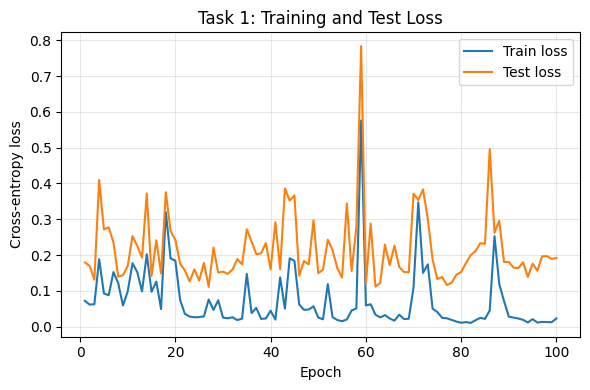

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(range(1, epochs + 1), train_losses, label="Train loss")
ax.plot(range(1, epochs + 1), test_losses, label="Test loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Task 1: Training and Test Loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Recall    (fraction of drowsy correctly detected): 0.9600
Precision (fraction of drowsy predictions correct): 0.9057


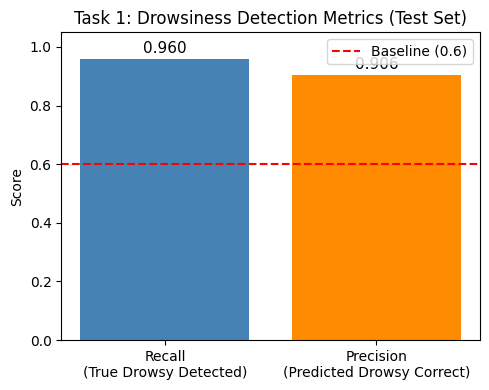

In [19]:
_, _, preds, labels = test(test_loader)

# drowsy = class 1
TP = ((preds == 1) & (labels == 1)).sum().item()
FN = ((preds == 0) & (labels == 1)).sum().item()
FP = ((preds == 1) & (labels == 0)).sum().item()

recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0

print(f'Recall    (fraction of drowsy correctly detected): {recall:.4f}')
print(f'Precision (fraction of drowsy predictions correct): {precision:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ['Recall\n(True Drowsy Detected)', 'Precision\n(Predicted Drowsy Correct)'],
    [recall, precision],
    color=['steelblue', 'darkorange']
)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.6, color='red', linestyle='--', label='Baseline (0.6)')
for bar, val in zip(bars, [recall, precision]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Task 1: Drowsiness Detection Metrics (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()

# Task 2

In [20]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

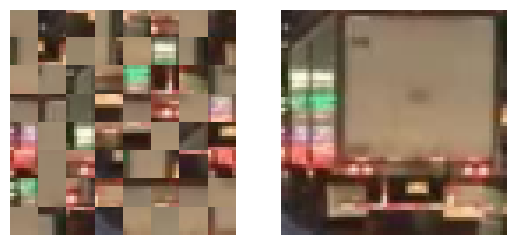

In [21]:
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=None,  # Fill train image transforms
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=None,  # Fill test image transforms
)

### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

## Task 3

In [22]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, backbone_arch: str, num_classes: int):
        super().__init__()
        self.backbone = None  # Here you can use a function that creates the backbone model based on the backbone_arch string (take a look here: https://docs.pytorch.org/vision/main/models.html)

        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.

        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.

        # TODO: define the trainable linear classification head
        self.linear_head = None

    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.

        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        pass